**Train** test split, 80% for training and 20% for testing

**Rule based optimization used**

Rule:-
Rewarding machine to going downward and penalizing to go upward

**Reward/Penalty function used**

**If going down**

weight cost = n1 * floor_diff * weight_factor

**If going up**

weight cost = n2 * floor_diff * weight_factor

n1 and n2 are arbitrary constant that are chosen based on multiple runs and optimized as 0.7 and 1.5 respectively. So it costs more 'power' if going up as compared to going down owing to the contribution done by gravity.

weight_factor = 1 + weight_of_lift




**Machine learning algorithm - Random Forest**

Saving elevator_dataset_24h_format.csv to elevator_dataset_24h_format (2).csv

Training Rush Hour Prediction Model...
Accuracy: 1.00

Optimizing Elevator Positions...


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:


Configuring ETA Prediction...

Generating Visualizations...


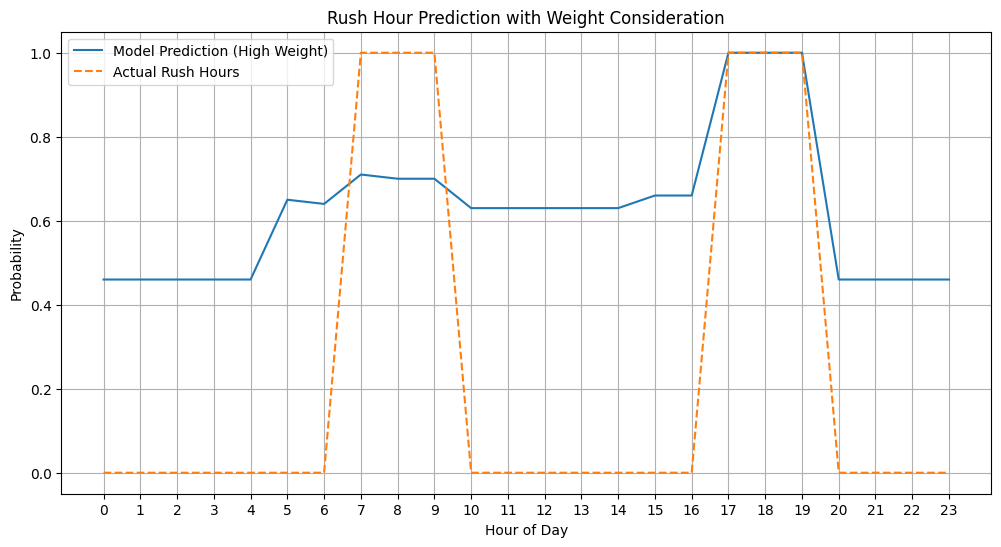

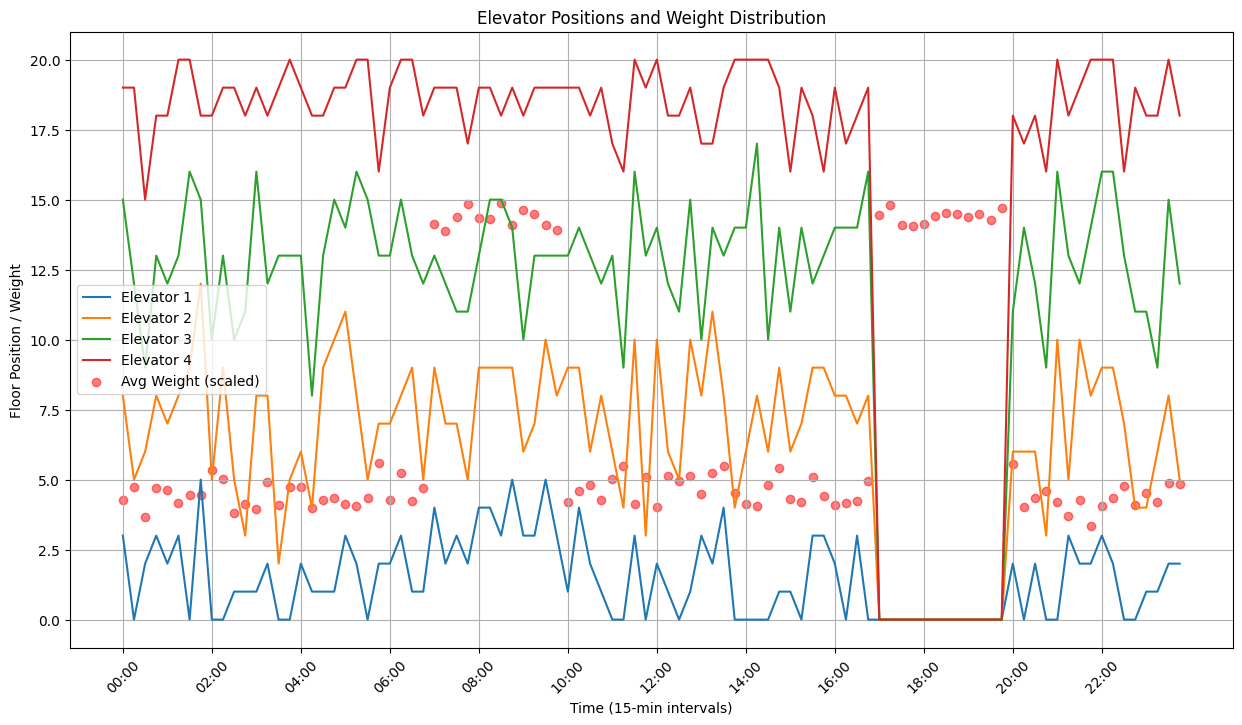


Real-time ETA Prediction Interface

Enter request time (HH:MM 24h format): 08:00
Enter request floor (0-20): 5

Nearest elevator on floor: 4
Predicted ETA: 0m 10s
Rush hour probability: 73%

Recommendations:
- ⚠️ High rush hour probability - expect delays

Processing Complete!


In [ ]:


# %% [code]
!pip install pandas numpy matplotlib scikit-learn scipy

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta

# %% [code]

uploaded = files.upload()
filename = next(iter(uploaded.keys()))
df = pd.read_csv(filename)


required_columns = ['datetime', 'start_floor', 'end_floor', 'speed_variation', 'is_rush_hour', 'weight']
if not all(col in df.columns for col in required_columns):
    raise ValueError("CSV missing required columns")

# Convert to datetime with proper handling of milliseconds
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')

df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute
df['time_window'] = (df['hour'] * 4) + (df['minute'] // 15)

# Normalize weight
df['weight_normalized'] = (df['weight'] - 80) / (800 - 80)


df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

# %% [code]

print("\nTraining Rush Hour Prediction Model...")
features = ['hour_sin', 'hour_cos', 'start_floor', 'end_floor', 'speed_variation', 'weight_normalized']
X = df[features]
y = df['is_rush_hour']

#split
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# %% [code]
print("\nOptimizing Elevator Positions...")

def power_cost(elevator_pos, request_floor, weight):
    floor_diff = abs(request_floor - elevator_pos)
    weight_factor = 1 + weight  # 1+weight scaling

    if request_floor > elevator_pos:
        return 1.5 * floor_diff * weight_factor
    else:
        return 0.7 * floor_diff * weight_factor

def optimize_elevators(requests, weights, n_elevators=4):
    if len(requests) == 0:
        return [0]*n_elevators

    requests = requests.reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_elevators, init='k-means++')
    kmeans.fit(requests, sample_weight=weights)

    refined_positions = []
    for cluster_id in range(n_elevators):
        cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]

        if len(cluster_indices) == 0:
            refined_positions.append(int(kmeans.cluster_centers_[cluster_id][0]))
            continue

        cluster_points = requests[cluster_indices].flatten()
        cluster_weights = weights[cluster_indices]

        # Find position minimizing weighted costs
        best_pos = min(cluster_points,
                      key=lambda x: sum(power_cost(x, req, w)
                                        for req, w in zip(cluster_points, cluster_weights)))
        refined_positions.append(int(best_pos))

    return sorted(refined_positions)

# Process in 15-minute windows
time_windows = df.groupby('time_window')
optimal_positions = []
for time, group in time_windows:
    positions = optimize_elevators(
        group['start_floor'].values,
        group['weight_normalized'].values
    )
    optimal_positions.append(positions)

# %% [code]
# ETA Prediction System
print("\nConfiguring ETA Prediction...")
ACCEL_DECEL_TIME = 3.0
FLOOR_HEIGHT = 4.0
BASE_SPEED = 1.0

def time_per_floor():
    """Calculate time per floor with acceleration/deceleration phases"""
    return (2 * ACCEL_DECEL_TIME) + (FLOOR_HEIGHT / BASE_SPEED)

TIME_PER_FLOOR = time_per_floor()  # About & seconds 2*3 of accel and decel time  + 1 s of base speed * floor_height which is 4(can be changed)

def get_user_input():
    """Get validated user input for ETA prediction"""
    while True:
        try:
            time_str = input("\nEnter request time (HH:MM 24h format): ")
            hour, minute = map(int, time_str.split(':'))
            floor = int(input("Enter request floor (0-20): "))
            if not (0 <= hour < 24 and 0 <= minute < 60):
                raise ValueError
            if not (0 <= floor <= 20):
                raise ValueError
            return (hour, minute), floor
        except:
            print("Invalid input! Use format HH:MM and floor 0-20")

def predict_eta(user_time, request_floor):
    """Predict ETA using optimized positions and ML model"""
    hour, minute = user_time
    time_window = (hour * 4) + (minute // 15)

    try:
        elevators = optimal_positions[time_window]
    except IndexError:
        elevators = optimal_positions[-1]  # Use last known positions


    nearest_elevator = min(elevators, key=lambda x: abs(x - request_floor))
    floors_to_travel = abs(nearest_elevator - request_floor)


    eta_seconds = floors_to_travel * TIME_PER_FLOOR

    # Predict rush hour probability
    rush_prob = model.predict_proba(pd.DataFrame([{
        'hour_sin': np.sin(2 * np.pi * hour/24),
        'hour_cos': np.cos(2 * np.pi * hour/24),
        'start_floor': request_floor,
        'end_floor': request_floor,
        'speed_variation': 1.0,
        'weight_normalized': 0.5
    }]))[0][1]

    return nearest_elevator, eta_seconds, rush_prob

# %% [code]

print("\nGenerating Visualizations...")

def plot_rush_hour_comparison(model):
    hours = np.arange(24)
    test_points = pd.DataFrame({
        'hour_sin': np.sin(2 * np.pi * hours/24),
        'hour_cos': np.cos(2 * np.pi * hours/24),
        'start_floor': 0,
        'end_floor': 10,
        'speed_variation': 1.0,
        'weight_normalized': 0.8  # High weight scenario
    })

    proba = model.predict_proba(test_points)[:,1]
    actual = [1 if (7 <= h <=9) or (17 <= h <=19) else 0 for h in hours]

    plt.figure(figsize=(12,6))
    plt.plot(hours, proba, label='Model Prediction (High Weight)')
    plt.plot(hours, actual, label='Actual Rush Hours', linestyle='--')
    plt.title('Rush Hour Prediction with Weight Consideration')
    plt.xlabel('Hour of Day')
    plt.ylabel('Probability')
    plt.legend()
    plt.xticks(range(24))
    plt.grid(True)
    plt.show()

def plot_elevator_strategy(positions, df):
    plt.figure(figsize=(15,8))
    time_labels = [f"{h:02d}:{m:02d}" for h in range(24) for m in [0,15,30,45]]

    # Plot elevator positions
    for elev_idx in range(4):
        elev_pos = [pos[elev_idx] if elev_idx < len(pos) else 0
                    for pos in positions]
        plt.plot(time_labels[:len(elev_pos)], elev_pos,
                 label=f'Elevator {elev_idx+1}')

    # Plot weight distribution
    weight_avg = df.groupby('time_window')['weight_normalized'].mean()
    plt.scatter(time_labels[:len(weight_avg)], weight_avg * 20,
                alpha=0.5, c='red', label='Avg Weight (scaled)')

    plt.title('Elevator Positions and Weight Distribution')
    plt.xlabel('Time (15-min intervals)')
    plt.ylabel('Floor Position / Weight')
    plt.xticks(time_labels[::8], rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_rush_hour_comparison(model)
plot_elevator_strategy(optimal_positions, df)

# %% [code]

print("\n" + "="*50)
print("Real-time ETA Prediction Interface")
print("="*50)


(user_time, req_floor) = get_user_input()


elevator_pos, eta_seconds, rush_prob = predict_eta(user_time, req_floor)


recommendations = []
if rush_prob > 0.65:
    recommendations.append("⚠️ High rush hour probability - expect delays")

if eta_seconds > 120 and req_floor <= 5:  # 2 minute threshold for <=5 floors
    recommendations.append(f"🚶 Consider stairs (ETA: {eta_seconds//60:.0f}m {eta_seconds%60:.0f}s)")


print(f"\nNearest elevator on floor: {elevator_pos}")
print(f"Predicted ETA: {eta_seconds//60:.0f}m {eta_seconds%60:.0f}s")
print(f"Rush hour probability: {rush_prob:.0%}")

if recommendations:
    print("\nRecommendations:")
    for r in recommendations:
        print(f"- {r}")

print("\nProcessing Complete!")
